# KAMA — does a moving average that *adapts* beat a plain one?
### Kaufman's Adaptive Moving Average, raced head-to-head against a fixed SMA

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a fixed SMA%3F: Busted](https://img.shields.io/badge/Beats_a_fixed_SMA%3F-Busted-8b949e?style=flat-square)

A plain moving average has one speed: it lags in trends and whipsaws in chop. Perry Kaufman's clever fix (1995) — the **Adaptive Moving Average (KAMA)** — measures how *efficient* the recent price path is (a clean straight line vs a sawtooth) and speeds up in trends, freezes in chop. The pitch: a buy-when-price-crosses-above rule on KAMA should beat the same rule on a fixed SMA — fewer whipsaws, faster entries. We test that *exact* claim.

> This is the plain-language layer. Want the *t*-stats, the permutation placebo, the cost and parameter sweeps? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3498db"

from kama_adaptive import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-05-31"
TICKERS = ["SPY", "QQQ", "IWM", "EFA", "GLD", "AAPL"]

def have_cache():
    return os.path.exists(data._cache_path("SPY", CACHE))

HAVE_REAL = have_cache()

def get(t):
    b = data.load_real(t, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first (real tape)

| Question | Answer |
|---|---|
| Does KAMA beat a plain SMA? | **No.** On SPY the KAMA book's net Sharpe is **+0.20** vs the SMA's **+0.53** — the adaptation is *worse*, significantly so (HAC *t* = **-2.98**). |
| Fewer whipsaws? | **No — more.** KAMA's turnover is **1269** vs the SMA's **765**. The 'fewer whipsaws' pitch is backwards here. |
| Beat just holding? | **No.** Buy-and-hold nets **+0.65** Sharpe; both filters lose to doing nothing. |
| Could you trade it? | **No.** It loses to both the simpler rule and to holding, and costs make its higher churn worse. |

> The Efficiency-Ratio idea is genuinely clever — it just doesn't help a price-cross rule on real index tapes. Numbers frozen as-of 2026-05-31; see [docs/results.md](../docs/results.md).

## 1 · The claim

> *"A fixed moving average is a compromise: too slow for trends, too fast for chop. KAMA fixes this — it measures the Efficiency Ratio (how much net distance the price covered vs how much it wiggled) and adapts its speed. In a clean trend it tracks like a fast EMA; in noise it freezes like a slow one. So a price-cross rule on KAMA gives fewer whipsaws and faster entries than the same rule on a plain SMA."*

Kaufman introduced this in *Smarter Trading* (1995). It is the headline 'adaptive' indicator on most charting platforms. We test whether the adaptation actually earns its keep — *measured against the simple thing it claims to beat.*

## 2 · So what?

If adapting to volatility genuinely beat a fixed window, it would be a free upgrade: same idea, smarter execution, less getting chopped up. Millions of traders pick indicators on exactly this 'smarter version' logic. But if the adaptation *doesn't* help — or actively hurts — then the extra machinery is just more knobs to overfit, and the plain moving average was the better tool all along.

## 3 · How would we know?

We make the race fair:

1. **Same rule, two filters.** Long when the close is above the filter, flat otherwise. Run it once with KAMA(10, 2, 30) and once with a fixed **SMA(30)** of matched length. The *difference* is the adaptation's contribution.
2. **One execution lag.** The signal at today's close earns *tomorrow's* return — one shift, no look-ahead.
3. **Charge real costs**, count turnover, and compare everything to **buy-and-hold** (because any trend filter that sits in cash part-time must be raced excess-vs-excess).

**The mirage line:** if KAMA − SMA isn't reliably *positive*, the adaptation adds nothing. We run it on six liquid tapes (SPY, QQQ, IWM, EFA, GLD, AAPL).

## 4 · The teardown — the head-to-head on SPY

Three equity curves on the same tape: hold, the plain SMA timing rule, and KAMA.

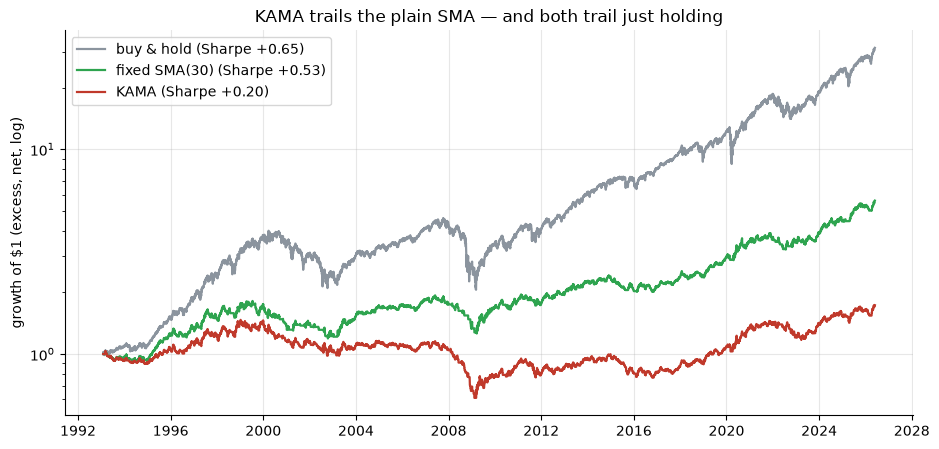

In [2]:
if HAVE_REAL:
    p = get('SPY')['close']
    k = st.kama(p); s = st.sma(p, 30)
    bk = st.book_excess(p, st.ma_positions(p, k), cost_bps=1.0)
    bs = st.book_excess(p, st.ma_positions(p, s), cost_bps=1.0)
    bh = st.buy_hold_excess(p)
    eqk = (1+bk).cumprod(); eqs = (1+bs).cumprod(); eqh = (1+bh).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(eqh.index, eqh, c=GREY, lw=1.6, label=f'buy & hold (Sharpe +{st.sharpe(bh):.2f})')
    ax.plot(eqs.index, eqs, c=GREEN, lw=1.6, label=f'fixed SMA(30) (Sharpe +{st.sharpe(bs):.2f})')
    ax.plot(eqk.index, eqk, c=RED, lw=1.6, label=f'KAMA (Sharpe +{st.sharpe(bk):.2f})')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess, net, log)')
    ax.set_title('KAMA trails the plain SMA — and both trail just holding'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('cached tape missing — frozen: KAMA +0.20, SMA +0.53, hold +0.65 (net Sharpe)')

The plain SMA (Sharpe **+0.53**) beats the adaptive KAMA (**+0.20**) — and **buy-and-hold (+0.65**) beats both. The 'smarter' filter is the worst of the three.

**Does the 'fewer whipsaws' promise hold? Look at turnover.**

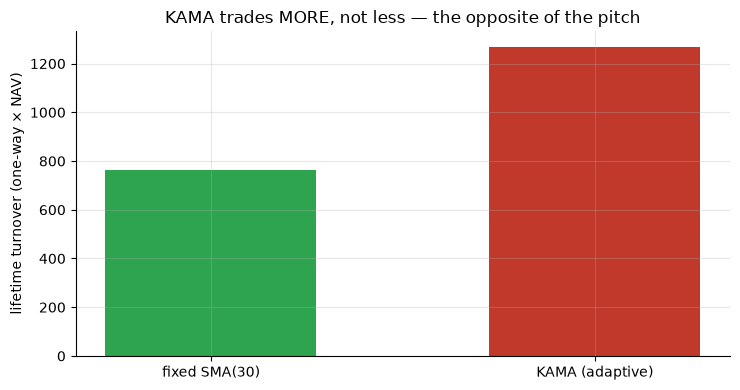

SMA turnover: 765   KAMA turnover: 1269


In [3]:
labels = ['fixed SMA(30)', 'KAMA (adaptive)']
if HAVE_REAL:
    turns = [st.ma_positions(p, s).diff().abs().sum(),
             st.ma_positions(p, k).diff().abs().sum()]
else:
    turns = [765, 1269]
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.bar(labels, turns, color=[GREEN, RED], width=.55)
ax.set_ylabel('lifetime turnover (one-way × NAV)')
ax.set_title('KAMA trades MORE, not less — the opposite of the pitch')
plt.tight_layout(); plt.show()
print(f'SMA turnover: {turns[0]:.0f}   KAMA turnover: {turns[1]:.0f}')

KAMA's lifetime turnover (**1269**) is *higher* than the plain SMA's (**765**). The squared smoothing constant keeps the filter creeping across the price even in chop — so the adaptation generates *extra* crossings, the exact reverse of the marketing.

**Is it just SPY? The whole basket.**

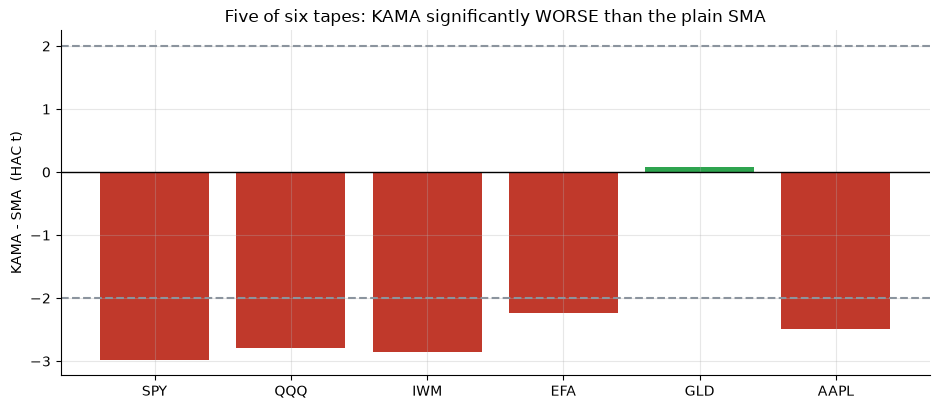

,ticker,KAMA Sharpe,SMA Sharpe,KAMA-SMA t
0,SPY,0.203,0.530,-2.977
1,QQQ,0.181,0.521,-2.790
2,IWM,-0.089,0.243,-2.855
3,EFA,0.168,0.421,-2.231
4,GLD,0.464,0.436,0.074
5,AAPL,0.579,0.766,-2.493


In [4]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        r = st.run_experiment(get(t)['close'], cost_bps=1.0)
        rows.append((t, r['kama_sharpe'], r['sma_sharpe'], r['diff_ks_t']))
else:
    lit = {
        'SPY': (0.203, 0.53, 0.65, -2.98),
        'QQQ': (0.181, 0.521, 0.523, -2.79),
        'IWM': (-0.089, 0.243, 0.472, -2.86),
        'EFA': (0.168, 0.421, 0.406, -2.23),
        'GLD': (0.464, 0.436, 0.666, 0.07),
        'AAPL': (0.579, 0.766, 0.628, -2.49),
    }
    rows = [(t, v[0], v[1], v[3]) for t, v in lit.items()]
tab = pd.DataFrame(rows, columns=['ticker','KAMA Sharpe','SMA Sharpe','KAMA-SMA t'])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
col = [GREEN if v > 0 else RED for v in tab['KAMA-SMA t']]
ax.bar(tab['ticker'], tab['KAMA-SMA t'], color=col)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('KAMA - SMA  (HAC t)')
ax.set_title('Five of six tapes: KAMA significantly WORSE than the plain SMA')
plt.tight_layout(); plt.show()
tab.round(3)

Only GLD ties; every equity tape is *significantly* behind the plain SMA, and none clears the +2 bar that 'KAMA beats SMA' would require.

## 5 · The verdict

- **Signal — None.** KAMA − SMA = **-1.39 bps/day**, HAC *t* = **-2.98** (significant, wrong side). Five of six tapes worse.
- **Tradability — Mirage.** Loses to the SMA *and* to buy-and-hold; turnover 1269 > 765, so costs widen the gap.
- **Beats a fixed SMA? — Busted.** The adaptation makes the rule worse and raises churn — the reverse of the 'fewer whipsaws' claim.

## 6 · Could you actually trade it?

There is nothing to deploy: the adaptive filter loses to the *simpler* filter, which loses to *holding*. And because KAMA trades more, every basis point of cost hurts it more than the SMA — the cost sweep below tilts the race further against it.

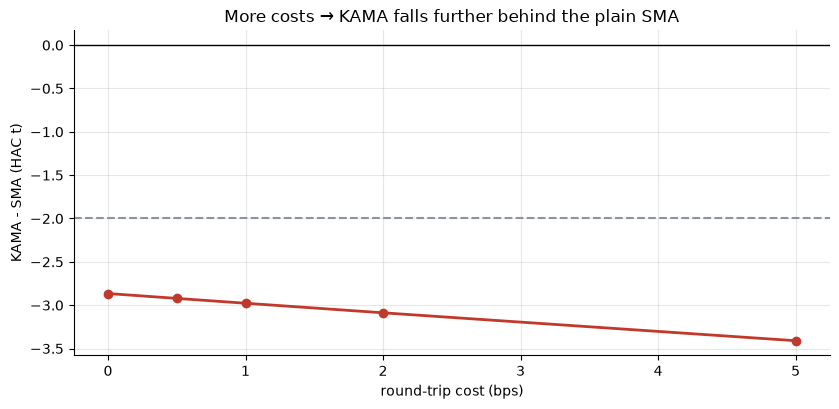

The KAMA-minus-SMA t-stat only gets more negative as costs rise.


In [5]:
costs = [c[0] for c in [(0.0, 0.237, 0.551, -1.327, -2.87), (0.5, 0.22, 0.54, -1.357, -2.92), (1.0, 0.203, 0.53, -1.387, -2.98), (2.0, 0.169, 0.509, -1.447, -3.09), (5.0, 0.067, 0.445, -1.627, -3.41)]]
if HAVE_REAL:
    kss = [st.run_experiment(get('SPY')['close'], cost_bps=c)['diff_ks_t'] for c in costs]
else:
    kss = [c[4] for c in [(0.0, 0.237, 0.551, -1.327, -2.87), (0.5, 0.22, 0.54, -1.357, -2.92), (1.0, 0.203, 0.53, -1.387, -2.98), (2.0, 0.169, 0.509, -1.447, -3.09), (5.0, 0.067, 0.445, -1.627, -3.41)]]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(costs, kss, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls='--', c=GREY)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('KAMA - SMA (HAC t)')
ax.set_title('More costs → KAMA falls further behind the plain SMA')
plt.tight_layout(); plt.show()
print('The KAMA-minus-SMA t-stat only gets more negative as costs rise.')

## 7 · Going further

- **The positive control.** The companion notebook shows a synthetic tape where trends and chop alternate sharply: there KAMA *does* beat the SMA (the harness works). The real market just isn't that regime.
- **Other adaptive filters.** [Supertrend](../../106-supertrend/) (ATR-adaptive) is KAMA's cousin — same family, same honest treatment.
- **The simpler benchmark wins.** This echoes [Bollinger](../../104-bollinger-reversion/) and [CCI](../../178-cci/): elaborate technical machinery rarely beats the plain version.

*Think KAMA shines on a different asset, timeframe, or rule (e.g. KAMA-slope, not price-cross)? Fork this, swap it in, and show a KAMA − SMA difference that clears *t* = +2. That is the bar.*